# Grupo 6 — Forecasting de emisiones de CO₂ (Área: Medio Ambiente)
**Práctica 1 — Entregable 3: Guía de código en Python (versión Jupyter Notebook)**
Universidad Nacional de Ingeniería — FIIS — Ciclo 2026-II

**Metodología:** CRISP-ML(Q) (Studer et al., 2021, https://doi.org/10.48550/arXiv.2003.05155)

Este notebook implementa **únicamente** las tres primeras fases de CRISP-ML(Q):

| Fase | Nombre | Qué produce |
|---|---|---|
| 1 | Business Understanding (Comprensión del negocio) | Objetivos, criterios de éxito y requisitos de calidad |
| 2 | Data Understanding (Comprensión de los datos) | Datos crudos, análisis exploratorio y reporte de calidad |
| 3 | Data Preparation (Preparación de los datos) | Dataset panel país-año limpio y validado |

Por indicación del curso, **no se incluye la fase de modelado**: no se entrena, ajusta ni ejecuta ningún algoritmo de Machine Learning. El producto final es un dataset listo para que la siguiente fase (Modeling) construya los modelos de pronóstico.

**Fuente de datos:** World Bank Open Data (API v2, https://data.worldbank.org). La serie de CO₂ del Banco Mundial proviene de la base EDGAR (JRC, Comisión Europea). Licencia: CC BY 4.0.

> Este notebook contiene el mismo código que `main.py`, organizado en celdas para ejecutarlo paso a paso y ver tablas y gráficos en pantalla. **Cómo usarlo:** colocarlo en la misma carpeta que `main.py` y ejecutar *Kernel → Restart & Run All*. La primera ejecución descarga los datos (requiere Internet); las siguientes usan la caché de `data/raw/`.

## 1. Importación de librerías
Además de las librerías de `main.py`, se usa `IPython.display` para mostrar tablas y gráficos dentro del notebook.

In [1]:
# =============================================================================
# 1. IMPORTACIÓN DE LIBRERÍAS
# =============================================================================
# Librerías estándar de Python
import argparse          # lectura de argumentos de línea de comandos
import json              # exportar reportes en formato JSON
import logging           # mensajes de progreso con marca de tiempo
import sys               # códigos de salida del programa
import time              # pausas entre reintentos de descarga
from datetime import datetime, timezone
from pathlib import Path  # manejo de rutas independiente del sistema operativo

# Librerías de terceros (ver requirements.txt)
import numpy as np        # cálculo numérico (logaritmos, estadísticos robustos)
import pandas as pd       # manipulación de datos tabulares (DataFrames)
import requests           # consumo de la API REST del Banco Mundial
import matplotlib         # generación de gráficos
import matplotlib.pyplot as plt
import seaborn as sns     # gráficos estadísticos (heatmaps, distribuciones)
from IPython.display import display, Markdown  # mostrar tablas y figuras en el notebook

%matplotlib inline

## 2. Configuración global
Rutas del proyecto, indicadores del Banco Mundial, umbrales de calidad y traducciones al español.

**Parámetros de ejecución** (en `main.py` se pasan por línea de comandos con `--actualizar` y `--pais`):
- `ACTUALIZAR = True` fuerza la descarga de los datos desde la API.
- `PAIS_REF` es el código ISO3 del país que se grafica en la figura 6 (por defecto Perú).

In [2]:
# Parámetros de ejecución (equivalen a los argumentos --actualizar y --pais de main.py)
ACTUALIZAR = False   # True: fuerza la descarga de los datos desde la API del Banco Mundial
PAIS_REF = "PER"     # código ISO3 del país de referencia para los gráficos

In [3]:
# =============================================================================
# 2. CONFIGURACIÓN GLOBAL
# =============================================================================
# Rutas del proyecto (relativas a la carpeta donde está este notebook)
BASE_DIR = Path.cwd()
DIR_RAW = BASE_DIR / "data" / "raw"              # datos originales descargados
DIR_PROCESADO = BASE_DIR / "data" / "processed"  # datos preparados (salida fase 3)
DIR_REPORTES = BASE_DIR / "reports"              # reportes en Markdown / JSON / CSV
DIR_FIGURAS = DIR_REPORTES / "figures"           # gráficos PNG

# API del Banco Mundial
WB_API = "https://api.worldbank.org/v2"
TIMEOUT_SEG = 60
REINTENTOS = 3

# Periodo de análisis
ANIO_INICIO = 1990
ANIO_FIN = 2024

# Variable objetivo del futuro modelo de forecasting
OBJETIVO = "co2_mt"

# Indicadores del Banco Mundial.
# codigo_wb -> (nombre_corto, descripción, tipo)
#   tipo = "nivel"      : magnitud positiva (se analiza en logaritmos)
#   tipo = "porcentaje" : valor acotado entre 0 y 100
INDICADORES = {
    "EN.GHG.CO2.MT.CE.AR5": ("co2_mt", "Emisiones de CO2 totales excl. LULUCF (Mt CO2e)", "nivel"),
    "EN.GHG.CO2.PC.CE.AR5": ("co2_pc", "Emisiones de CO2 per cápita excl. LULUCF (t CO2e/hab)", "nivel"),
    "NY.GDP.MKTP.KD":       ("pib", "PIB a precios constantes de 2015 (US$)", "nivel"),
    "NY.GDP.PCAP.KD":       ("pib_pc", "PIB per cápita a precios constantes de 2015 (US$)", "nivel"),
    "SP.POP.TOTL":          ("poblacion", "Población total (habitantes)", "nivel"),
    "SP.URB.TOTL.IN.ZS":    ("urbano_pct", "Población urbana (% del total)", "porcentaje"),
    "EG.FEC.RNEW.ZS":       ("renovable_pct", "Consumo de energía renovable (% del consumo final)", "porcentaje"),
    "EG.USE.PCAP.KG.OE":    ("energia_pc", "Uso de energía (kg equivalente de petróleo per cápita)", "nivel"),
    "EG.USE.COMM.FO.ZS":    ("fosil_pct", "Consumo de energía de combustibles fósiles (% del total)", "porcentaje"),
    "EG.ELC.ACCS.ZS":       ("electricidad_pct", "Acceso a la electricidad (% de la población)", "porcentaje"),
    "NV.IND.TOTL.ZS":       ("industria_pct", "Industria incl. construcción, valor agregado (% del PIB)", "porcentaje"),
    "EG.ELC.COAL.ZS":       ("carbon_elec_pct", "Electricidad producida con carbón (% del total)", "porcentaje"),
}
NOMBRE_VAR = {codigo: v[0] for codigo, v in INDICADORES.items()}
DESC_VAR = {v[0]: v[1] for v in INDICADORES.values()}
TIPO_VAR = {v[0]: v[2] for v in INDICADORES.values()}

# Parámetros de calidad / preparación (definidos como requisitos en la fase 1)
UMBRAL_FALTANTES_VARIABLE = 0.30   # se descarta una variable con más de 30 % de faltantes
UMBRAL_COBERTURA_OBJETIVO = 0.90   # un país se conserva si tiene CO2 en >= 90 % de los años
MIN_PAISES = 150                   # mínimo de países para que el panel sea representativo
LIMITE_INTERPOLACION = 5           # máximo de años consecutivos que se interpolan
LIMITE_EXTREMOS = 3                # máximo de años que se rellenan en los bordes de la serie
UMBRAL_Z_ROBUSTO = 3.5             # umbral del z-score robusto (Iglewicz y Hoaglin)
SALTO_MINIMO = {"nivel": 0.15, "porcentaje": 5.0}  # magnitud mínima de un salto anómalo:
                                   # 15 % (variación log) en niveles, 5 puntos en porcentajes
TOLERANCIA_CONSISTENCIA = 0.05     # 5 % de diferencia máxima entre CO2 total y per cápita x población
MIN_CO2_PC_PLAUSIBLE = 0.01        # t CO2/hab; los países más pobres emiten ~0.04, valores menores
                                   # indican que el país no se mide por separado (p. ej., territorios)
ANIOS_SHOCK = {2009: "Crisis financiera global", 2020: "Pandemia COVID-19"}
N_REZAGOS_OBJETIVO = 3             # rezagos de CO2 (t-1, t-2, t-3) como variables explicativas

# Traducción de las categorías del Banco Mundial (la API las entrega en inglés).
# nombre original -> (nombre en español, sufijo de la columna indicadora)
REGIONES_ES = {
    "East Asia & Pacific": ("Asia Oriental y Pacífico", "asia_oriental_pacifico"),
    "Europe & Central Asia": ("Europa y Asia Central", "europa_asia_central"),
    "Latin America & Caribbean": ("América Latina y el Caribe", "america_latina_caribe"),
    "Middle East, North Africa, Afghanistan & Pakistan":
        ("Medio Oriente, Norte de África, Afganistán y Pakistán", "medio_oriente_norte_africa"),
    "North America": ("América del Norte", "america_norte"),
    "South Asia": ("Asia del Sur", "asia_sur"),
    "Sub-Saharan Africa": ("África Subsahariana", "africa_subsahariana"),
}
INGRESOS_ES = {
    "High income": ("Ingreso alto", "alto"),
    "Upper middle income": ("Ingreso medio alto", "medio_alto"),
    "Lower middle income": ("Ingreso medio bajo", "medio_bajo"),
    "Low income": ("Ingreso bajo", "bajo"),
    "Not classified": ("Sin clasificar", "sin_clasificar"),
}

# Partición temporal sugerida para la fase de modelado (aquí solo se etiqueta)
PARTICION = {"entrenamiento": (None, 2016), "validacion": (2017, 2020), "prueba": (2021, ANIO_FIN)}

# Configuración de mensajes en consola
logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)-7s | %(message)s",
                    datefmt="%H:%M:%S", stream=sys.stdout, force=True)
log = logging.getLogger("grupo6_co2")

# Estilo de los gráficos
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "savefig.bbox": "tight"})

## 3. Funciones auxiliares
Funciones de apoyo usadas en las tres fases: creación de carpetas, guardado de figuras, logaritmo seguro, reglas de validez y z-score robusto.

A diferencia de `main.py`, `guardar_figura` además **muestra** cada gráfico en el notebook.

In [4]:
# =============================================================================
# 3. FUNCIONES AUXILIARES
# =============================================================================
def crear_directorios() -> None:
    """Crea las carpetas de salida si no existen."""
    for d in (DIR_RAW, DIR_PROCESADO, DIR_REPORTES, DIR_FIGURAS):
        d.mkdir(parents=True, exist_ok=True)


def titulo(texto: str) -> None:
    """Imprime un encabezado visible en consola para separar las fases."""
    linea = "=" * 78
    print(f"\n{linea}\n {texto}\n{linea}")


def guardar_figura(fig: plt.Figure, nombre: str) -> Path:
    """Guarda una figura en reports/figures, la muestra en el notebook y libera la memoria."""
    ruta = DIR_FIGURAS / nombre
    fig.savefig(ruta)
    display(fig)
    plt.close(fig)
    log.info("Figura guardada: %s", ruta.relative_to(BASE_DIR))
    return ruta


def tabla_markdown(df: pd.DataFrame, indice: bool = False) -> str:
    """Convierte un DataFrame en una tabla Markdown sin dependencias extra."""
    if indice:
        df = df.reset_index()
    columnas = [str(c) for c in df.columns]
    filas = ["| " + " | ".join(columnas) + " |", "|" + "---|" * len(columnas)]
    for _, fila in df.iterrows():
        valores = []
        for v in fila:
            if isinstance(v, float):
                valores.append("" if pd.isna(v) else f"{v:,.2f}")
            else:
                valores.append(str(v))
        filas.append("| " + " | ".join(valores) + " |")
    return "\n".join(filas)


def log_seguro(serie: pd.Series) -> pd.Series:
    """Logaritmo natural que devuelve NaN (en vez de -inf) para valores <= 0."""
    return np.log(serie.where(serie > 0))


def fuera_de_rango(serie: pd.Series, var: str) -> pd.Series:
    """
    Regla de validez: los porcentajes deben estar en [0, 100] y las variables de
    nivel (CO2, PIB, población, energía) deben ser estrictamente positivas: un
    país habitado no puede tener 0 emisiones ni 0 PIB (un 0 indica dato no medido).
    """
    if TIPO_VAR[var] == "porcentaje":
        return (serie < 0) | (serie > 100)
    return serie <= 0


def objetivo_valido(panel: pd.DataFrame) -> pd.Series:
    """
    Marca como válido el CO2 de un país-año si es positivo y su valor per cápita
    es plausible (>= 0.01 t/hab). Los ceros o valores ínfimos corresponden a
    países cuyas emisiones no se miden por separado, no a emisiones reales.
    """
    return (panel[OBJETIVO] > 0) & ~(panel["co2_pc"] < MIN_CO2_PC_PLAUSIBLE)


def z_robusto(serie: pd.Series) -> pd.Series:
    """
    Z-score robusto basado en la mediana y la MAD (Median Absolute Deviation):
        z = 0.6745 * (x - mediana) / MAD
    Es resistente a los propios outliers, a diferencia del z-score clásico.
    """
    mediana = serie.median()
    mad = (serie - mediana).abs().median()
    if pd.isna(mad) or mad == 0:
        return pd.Series(0.0, index=serie.index)
    return 0.6745 * (serie - mediana) / mad

In [5]:
# Se crean las carpetas de salida: data/raw, data/processed, reports y reports/figures
crear_directorios()
inicio = time.time()

## 4. Fase 1 — Business Understanding (Comprensión del negocio)
Se definen el problema, los objetivos de negocio y de minería de datos, los criterios de éxito y los **requisitos de calidad (QA gates)** que se verifican automáticamente en las fases 2 y 3.

**Resultado esperado:** `reports/01_business_understanding.md` y `reports/01_business_understanding.json`.

In [6]:
def fase1_business_understanding() -> dict:
    """
    Define el problema, los objetivos de negocio y de minería de datos, los
    criterios de éxito y los requisitos de calidad (QA gates) que se verifican
    en las fases 2 y 3.

    Resultado esperado:
        - reports/01_business_understanding.md (documento legible)
        - reports/01_business_understanding.json (requisitos usados por el código)
    """
    titulo("FASE 1 - BUSINESS UNDERSTANDING")

    negocio = {
        "tema": "Forecasting de emisiones de CO2",
        "area": "Medio Ambiente",
        "contexto": (
            "Los países firmantes del Acuerdo de París deben reportar y cumplir sus "
            "Contribuciones Determinadas a Nivel Nacional (NDC). En el caso del Perú, la NDC "
            "actualizada en 2020 plantea reducir hasta 40 % de sus emisiones de GEI respecto "
            "al escenario tendencial (BAU) al 2030. Anticipar la trayectoria de las emisiones "
            "de CO2 permite a los ministerios de ambiente y energía evaluar si las políticas "
            "vigentes son suficientes y priorizar medidas de transición energética."
        ),
        "problema": (
            "Las cifras oficiales de emisiones se publican con 1-2 años de rezago y no dicen "
            "hacia dónde se dirige cada país. Se requiere un insumo cuantitativo para "
            "pronosticar las emisiones de CO2 por país a partir de sus determinantes "
            "económicos, demográficos y energéticos."
        ),
        "interesados": [
            "Ministerios de Ambiente y de Energía y Minas (p. ej., MINAM y MINEM en el Perú)",
            "Organismos multilaterales y bancos de desarrollo (financiamiento climático)",
            "Investigadores y ONG ambientales",
        ],
        "objetivo_negocio": (
            "Contar con estimaciones anticipadas (horizonte de 1 a 5 años) de las emisiones "
            "de CO2 por país para evaluar la brecha frente a las metas NDC y priorizar "
            "políticas de mitigación."
        ),
        "objetivo_mineria_datos": (
            "Construir un dataset panel país-año (1990-2024) limpio, sin valores faltantes, "
            "con variables explicativas rezagadas y sin fuga de información, que permita en la "
            "siguiente fase entrenar modelos de regresión/series de tiempo que pronostiquen las "
            "emisiones totales de CO2 (Mt CO2e) de cada país."
        ),
        "criterios_exito": {
            "negocio": "Que el pronóstico permita identificar con al menos 1 año de anticipación "
                       "a los países que se alejan de su trayectoria de reducción.",
            "machine_learning": "MAPE < 10 % en el periodo de prueba temporal (2021-2024); "
                                "se evaluará en la fase de modelado, fuera del alcance de este trabajo.",
            "economico": "Usar exclusivamente datos abiertos y software libre (costo de licencias = 0).",
        },
        "alcance": "Fases 1 a 3 de CRISP-ML(Q). No se entrena ni ejecuta ningún modelo.",
        "supuestos": [
            "Las emisiones de CO2 dependen de la actividad económica (PIB), la población, "
            "la estructura energética y la urbanización (identidad de Kaya / modelo STIRPAT).",
            "Las series del Banco Mundial son comparables entre países y en el tiempo.",
        ],
        "riesgos": [
            "Indicadores energéticos discontinuados (el Banco Mundial dejó de actualizar algunos).",
            "Choques exógenos (crisis 2009, COVID-19 2020) que alteran la tendencia.",
            "Mezcla de países con agregados regionales en la API (doble conteo).",
            "Escalas muy distintas entre países (China vs. pequeños estados insulares).",
            "Fuga de información si se usan variables derivadas del objetivo en el mismo año.",
        ],
    }

    # Requisitos de calidad (QA gates): se revisan automáticamente en las fases 2 y 3.
    requisitos = {
        "periodo": [ANIO_INICIO, ANIO_FIN],
        "min_paises": MIN_PAISES,
        "cobertura_minima_objetivo_por_pais": UMBRAL_COBERTURA_OBJETIVO,
        "max_faltantes_por_variable": UMBRAL_FALTANTES_VARIABLE,
        "max_nulos_dataset_final": 0,
        "max_duplicados_pais_anio": 0,
        "rangos_validos": {"porcentajes": [0, 100], "niveles": "valores > 0",
                           "co2_per_capita_minimo_t": MIN_CO2_PC_PLAUSIBLE},
        "consistencia_co2_total_vs_per_capita": TOLERANCIA_CONSISTENCIA,
        "series_sin_huecos_temporales": True,
        "sin_fuga_de_informacion": True,
    }

    # Documento Markdown de la fase 1
    md = [
        "# Fase 1 - Business Understanding",
        f"**Tema:** {negocio['tema']}  \n**Área:** {negocio['area']}",
        "## Contexto", negocio["contexto"],
        "## Problema", negocio["problema"],
        "## Interesados", "\n".join(f"- {i}" for i in negocio["interesados"]),
        "## Objetivo de negocio", negocio["objetivo_negocio"],
        "## Objetivo de minería de datos", negocio["objetivo_mineria_datos"],
        "## Criterios de éxito",
        "\n".join(f"- **{k.replace('_', ' ').capitalize()}:** {v}" for k, v in negocio["criterios_exito"].items()),
        "## Alcance", negocio["alcance"],
        "## Supuestos", "\n".join(f"- {s}" for s in negocio["supuestos"]),
        "## Riesgos identificados", "\n".join(f"- {r}" for r in negocio["riesgos"]),
        "## Requisitos de calidad (QA gates)",
        "```json\n" + json.dumps(requisitos, indent=2, ensure_ascii=False) + "\n```",
    ]
    (DIR_REPORTES / "01_business_understanding.md").write_text("\n\n".join(md), encoding="utf-8")
    (DIR_REPORTES / "01_business_understanding.json").write_text(
        json.dumps({"negocio": negocio, "requisitos": requisitos}, indent=2, ensure_ascii=False),
        encoding="utf-8")

    print(f"Objetivo de negocio      : {negocio['objetivo_negocio']}")
    print(f"Objetivo de minería      : {negocio['objetivo_mineria_datos']}")
    print(f"Criterio de éxito (ML)   : {negocio['criterios_exito']['machine_learning']}")
    log.info("Reporte de la fase 1 guardado en reports/01_business_understanding.md")
    return {"negocio": negocio, "requisitos": requisitos}

In [7]:
fase1 = fase1_business_understanding()
requisitos = fase1["requisitos"]

# Requisitos de calidad que se verificarán en las fases 2 y 3
pd.Series({k: str(v) for k, v in requisitos.items()}, name="valor").to_frame()


 FASE 1 - BUSINESS UNDERSTANDING
Objetivo de negocio      : Contar con estimaciones anticipadas (horizonte de 1 a 5 años) de las emisiones de CO2 por país para evaluar la brecha frente a las metas NDC y priorizar políticas de mitigación.
Objetivo de minería      : Construir un dataset panel país-año (1990-2024) limpio, sin valores faltantes, con variables explicativas rezagadas y sin fuga de información, que permita en la siguiente fase entrenar modelos de regresión/series de tiempo que pronostiquen las emisiones totales de CO2 (Mt CO2e) de cada país.
Criterio de éxito (ML)   : MAPE < 10 % en el periodo de prueba temporal (2021-2024); se evaluará en la fase de modelado, fuera del alcance de este trabajo.
16:58:19 | INFO    | Reporte de la fase 1 guardado en reports/01_business_understanding.md


,valor
periodo,"[1990, 2024]"
min_paises,150
cobertura_minima_objetivo_por_pais,0.9
max_faltantes_por_variable,0.3
max_nulos_dataset_final,0
max_duplicados_pais_anio,0
rangos_validos,"{'porcentajes': [0, 100], 'niveles': 'valores ..."
consistencia_co2_total_vs_per_capita,0.05
series_sin_huecos_temporales,True
sin_fuga_de_informacion,True


## 5. Fase 2 — Data Understanding (Comprensión de los datos)
### 5.1 Recolección inicial de datos
Se descargan 12 indicadores y los metadatos de países desde la API del Banco Mundial. Los datos se guardan en `data/raw/` (caché) para que el resultado sea reproducible y el notebook funcione sin Internet en las siguientes ejecuciones. Luego se construye el **panel país-año** (una fila por país y año, una columna por indicador), excluyendo los agregados regionales.

In [8]:
def _get_json(sesion: requests.Session, url: str, params: dict) -> list:
    """GET a la API con reintentos; devuelve la respuesta JSON [metadatos, registros]."""
    for intento in range(1, REINTENTOS + 1):
        try:
            resp = sesion.get(url, params=params, timeout=TIMEOUT_SEG)
            resp.raise_for_status()
            datos = resp.json()
            if isinstance(datos, list) and len(datos) == 2:
                return datos
            raise ValueError(f"Respuesta inesperada de la API: {str(datos)[:200]}")
        except (requests.RequestException, ValueError) as err:
            log.warning("Intento %d/%d fallido para %s: %s", intento, REINTENTOS, url, err)
            time.sleep(2 * intento)
    raise ConnectionError(f"No se pudo descargar {url}")


def descargar_indicador(sesion: requests.Session, codigo: str) -> pd.DataFrame:
    """Descarga un indicador para todos los países/agregados en el periodo de análisis."""
    url = f"{WB_API}/country/all/indicator/{codigo}"
    params = {"format": "json", "per_page": 20000, "date": f"{ANIO_INICIO}:{ANIO_FIN}", "page": 1}
    filas = []
    while True:
        meta, registros = _get_json(sesion, url, params)
        for r in registros or []:
            filas.append({
                "iso3": r.get("countryiso3code") or "",
                "entidad": r["country"]["value"],
                "anio": int(r["date"]),
                "indicador": codigo,
                "valor": r["value"],
            })
        if params["page"] >= int(meta.get("pages", 1)):
            break
        params["page"] += 1
    return pd.DataFrame(filas)


def descargar_metadatos_paises(sesion: requests.Session) -> pd.DataFrame:
    """Descarga la región, nivel de ingreso y tipo (país o agregado) de cada entidad."""
    _, registros = _get_json(sesion, f"{WB_API}/country", {"format": "json", "per_page": 500})
    return pd.DataFrame([{
        "iso3": r["id"],
        "pais": r["name"],
        "region": r["region"]["value"].strip(),
        "nivel_ingreso": r["incomeLevel"]["value"].strip(),
        "es_agregado": r["region"]["value"].strip() == "Aggregates",
    } for r in registros])


def traducir_metadatos(meta: pd.DataFrame) -> pd.DataFrame:
    """
    Traduce al español la región y el nivel de ingreso de cada país. Los
    agregados (región 'Aggregates') no se traducen porque se excluyen del panel.
    Los datos crudos de data/raw se conservan tal como los entrega la API.
    """
    meta = meta.copy()
    meta["region"] = meta["region"].map(lambda r: REGIONES_ES.get(r, (r, None))[0])
    meta["nivel_ingreso"] = meta["nivel_ingreso"].map(lambda n: INGRESOS_ES.get(n, (n, None))[0])
    return meta


def recolectar_datos(actualizar: bool = False) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Recolección inicial de datos. Descarga los indicadores y metadatos desde la
    API del Banco Mundial y los guarda en data/raw (caché). Si la caché existe y
    no se pide --actualizar, se reutiliza para que el resultado sea reproducible
    y el script funcione sin conexión a Internet.
    """
    ruta_datos = DIR_RAW / "wb_indicadores_raw.csv"
    ruta_meta = DIR_RAW / "wb_paises_metadata.csv"

    if ruta_datos.exists() and ruta_meta.exists() and not actualizar:
        log.info("Usando datos en caché: %s", ruta_datos.relative_to(BASE_DIR))
        return pd.read_csv(ruta_datos, keep_default_na=False, na_values=[""]), \
            pd.read_csv(ruta_meta, keep_default_na=False, na_values=[""])

    log.info("Descargando %d indicadores desde la API del Banco Mundial...", len(INDICADORES))
    with requests.Session() as sesion:
        partes = []
        for codigo, (nombre, _, _) in INDICADORES.items():
            df = descargar_indicador(sesion, codigo)
            log.info("  %-22s -> %-16s %6d registros", codigo, nombre, len(df))
            partes.append(df)
        datos = pd.concat(partes, ignore_index=True)
        meta = descargar_metadatos_paises(sesion)

    datos.to_csv(ruta_datos, index=False)
    meta.to_csv(ruta_meta, index=False)
    (DIR_RAW / "fuente.json").write_text(json.dumps({
        "fuente": "World Bank Open Data - API v2",
        "url": WB_API,
        "indicadores": {k: v[1] for k, v in INDICADORES.items()},
        "periodo": f"{ANIO_INICIO}-{ANIO_FIN}",
        "fecha_descarga_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
        "licencia": "CC BY 4.0",
    }, indent=2, ensure_ascii=False), encoding="utf-8")
    log.info("Datos crudos guardados en data/raw/")
    return datos, meta


def construir_panel(datos: pd.DataFrame, meta: pd.DataFrame) -> tuple[pd.DataFrame, int]:
    """
    Convierte los datos largos (una fila por país-año-indicador) en un panel
    ancho (una fila por país-año, una columna por indicador) y separa los
    países de los agregados regionales (World, América Latina, etc.).
    Devuelve el panel de países y el número de duplicados encontrados.
    """
    datos = datos[datos["iso3"].notna() & (datos["iso3"] != "")].copy()
    datos["variable"] = datos["indicador"].map(NOMBRE_VAR)

    # Control de duplicados en los datos crudos (misma entidad, año e indicador)
    n_duplicados = int(datos.duplicated(subset=["iso3", "anio", "variable"]).sum())
    datos = datos.drop_duplicates(subset=["iso3", "anio", "variable"], keep="first")

    panel = (datos.pivot(index=["iso3", "anio"], columns="variable", values="valor")
             .reset_index().rename_axis(columns=None))
    paises = set(meta.loc[~meta["es_agregado"], "iso3"])
    panel = panel[panel["iso3"].isin(paises)].sort_values(["iso3", "anio"]).reset_index(drop=True)
    columnas = ["iso3", "anio"] + [v[0] for v in INDICADORES.values()]
    return panel[columnas], n_duplicados

### 5.2 Exploración de variables y relaciones (EDA)
Estadísticas descriptivas, tendencia global, principales emisores, distribución del objetivo, correlaciones y serie del país de referencia (figuras fig01 a fig06).

In [9]:
def explorar_datos(datos: pd.DataFrame, panel: pd.DataFrame, meta: pd.DataFrame,
                   pais_ref: str) -> dict:
    """
    Análisis exploratorio (EDA): estadísticas descriptivas, tendencia global,
    principales emisores, distribución del objetivo, relaciones entre variables
    y la serie del país de referencia. Genera las figuras fig01 a fig06.
    """
    variables = [v[0] for v in INDICADORES.values()]
    resumen = panel[variables].describe().T
    resumen["faltantes_pct"] = panel[variables].isna().mean() * 100
    resumen.to_csv(DIR_REPORTES / "02_estadisticas_descriptivas.csv")
    print("\nEstadísticas descriptivas (datos crudos, países):")
    with pd.option_context("display.float_format", "{:,.2f}".format, "display.width", 160,
                           "display.max_columns", 20):
        print(resumen[["count", "mean", "50%", "min", "max", "faltantes_pct"]])

    # fig01 - Tendencia global (agregado 'WLD' del Banco Mundial)
    mundo = datos[(datos["iso3"] == "WLD") & (datos["indicador"] == "EN.GHG.CO2.MT.CE.AR5")]
    mundo = mundo.dropna(subset=["valor"]).sort_values("anio")
    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.plot(mundo["anio"], mundo["valor"] / 1000, marker="o", ms=3, color="#b03a2e")
    for anio, evento in ANIOS_SHOCK.items():
        ax.axvline(anio, ls="--", color="gray", lw=1)
        ax.text(anio + 0.3, ax.get_ylim()[0] + 0.5, evento, rotation=90, fontsize=8, color="gray")
    ax.set(title="Emisiones mundiales de CO2 (excl. LULUCF)", xlabel="Año", ylabel="Gt CO2e")
    guardar_figura(fig, "fig01_tendencia_global_co2.png")

    # fig02 - Top 10 emisores en el último año con datos
    ultimo = int(panel.dropna(subset=[OBJETIVO])["anio"].max())
    top = (panel[panel["anio"] == ultimo].merge(meta[["iso3", "pais"]], on="iso3")
           .nlargest(10, OBJETIVO))
    fig, ax = plt.subplots(figsize=(9, 4.5))
    sns.barplot(data=top, x=OBJETIVO, y="pais", ax=ax, color="#c0392b")
    ax.set(title=f"Top 10 países emisores de CO2 ({ultimo})", xlabel="Mt CO2e", ylabel="")
    guardar_figura(fig, "fig02_top10_emisores.png")

    # fig03 - Distribución del objetivo: escala original vs. logarítmica
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    sns.histplot(panel[OBJETIVO].dropna(), bins=50, ax=axes[0], color="#7f8c8d")
    axes[0].set(title="CO2 total (escala original)", xlabel="Mt CO2e")
    sns.histplot(log_seguro(panel[OBJETIVO]).dropna(), bins=50, ax=axes[1], color="#27ae60")
    axes[1].set(title="CO2 total (escala logarítmica)", xlabel="ln(Mt CO2e)")
    fig.suptitle("La distribución es muy asimétrica: se justifica la transformación logarítmica")
    guardar_figura(fig, "fig03_distribucion_objetivo.png")

    # fig04 - Correlaciones de Spearman (robustas a no linealidad y outliers)
    corr = panel[variables].corr(method="spearman")
    fig, ax = plt.subplots(figsize=(9, 7.5))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
                ax=ax, annot_kws={"size": 7})
    ax.set_title("Correlación de Spearman entre variables")
    guardar_figura(fig, "fig04_correlaciones.png")

    # fig05 - Relación PIB vs. CO2 (en logaritmos) por región
    corte = panel[(panel["anio"] == ultimo) & (panel[OBJETIVO] > 0) & (panel["pib"] > 0)]
    corte = corte.merge(meta[["iso3", "region"]], on="iso3")
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.scatterplot(data=corte, x=np.log10(corte["pib"]), y=np.log10(corte[OBJETIVO]),
                    hue="region", ax=ax, s=40, alpha=0.8)
    ax.set(title=f"PIB vs. emisiones de CO2 por país ({ultimo})",
           xlabel="log10(PIB, US$ 2015)", ylabel="log10(CO2, Mt)")
    ax.legend(fontsize=7, loc="upper left")
    guardar_figura(fig, "fig05_pib_vs_co2.png")

    # fig06 - Serie del país de referencia
    ref = panel[panel["iso3"] == pais_ref].sort_values("anio")
    nombre_ref = meta.loc[meta["iso3"] == pais_ref, "pais"].squeeze() if pais_ref in set(meta["iso3"]) else pais_ref
    fig, ax1 = plt.subplots(figsize=(10, 4.5))
    ax1.plot(ref["anio"], ref[OBJETIVO], color="#b03a2e", marker="o", ms=3, label="CO2 (Mt)")
    ax1.set_ylabel("Mt CO2e", color="#b03a2e")
    ax2 = ax1.twinx()
    ax2.plot(ref["anio"], ref["pib"] / 1e9, color="#2471a3", ls="--", label="PIB (miles de millones US$)")
    ax2.set_ylabel("PIB (miles de millones US$ 2015)", color="#2471a3")
    ax2.grid(False)
    ax1.set(title=f"{nombre_ref}: emisiones de CO2 y PIB", xlabel="Año")
    guardar_figura(fig, "fig06_serie_pais_referencia.png")

    corr_objetivo = corr[OBJETIVO].drop(OBJETIVO).sort_values(key=abs, ascending=False)
    print("\nCorrelación de Spearman con el objetivo (co2_mt):")
    print(corr_objetivo.round(3).to_string())
    return {"ultimo_anio_objetivo": ultimo, "top10": top[["pais", OBJETIVO]].round(1).values.tolist(),
            "corr_objetivo": corr_objetivo.round(3).to_dict(), "resumen": resumen}

### 5.3 Evaluación de la calidad de los datos
Se evalúan cinco dimensiones (completitud, validez, unicidad, consistencia y exactitud) y se contrasta la factibilidad con los requisitos de la fase 1 (figura fig07).

In [10]:
def evaluar_calidad(panel: pd.DataFrame, n_duplicados: int) -> tuple[pd.DataFrame, dict]:
    """
    Evalúa la calidad de cada variable en cinco dimensiones:
      1. Completitud  : porcentaje de valores faltantes y último año disponible.
      2. Validez      : valores fuera de rango (negativos, porcentajes > 100).
      3. Unicidad     : registros duplicados país-año.
      4. Consistencia : CO2 total vs. CO2 per cápita x población.
      5. Exactitud    : outliers transversales (IQR) y saltos anómalos en el tiempo.
    Además identifica ceros no plausibles en el objetivo (países sin medición).
    Genera fig07 (mapa de faltantes) y el reporte 02_calidad_datos.csv.
    """
    variables = [v[0] for v in INDICADORES.values()]
    filas = []
    for var in variables:
        serie = panel[var]
        con_dato = panel.loc[serie.notna(), "anio"]
        invalidos = int(fuera_de_rango(serie, var).sum())
        # Outliers transversales con IQR sobre el logaritmo (los niveles son asimétricos)
        base = log_seguro(serie).dropna() if TIPO_VAR[var] == "nivel" else serie.dropna()
        q1, q3 = base.quantile([0.25, 0.75])
        iqr = q3 - q1
        outliers_iqr = int(((base < q1 - 1.5 * iqr) | (base > q3 + 1.5 * iqr)).sum())
        filas.append({
            "variable": var,
            "descripcion": DESC_VAR[var],
            "faltantes_pct": round(serie.isna().mean() * 100, 2),
            "paises_con_datos": int(panel.loc[serie.notna(), "iso3"].nunique()),
            "primer_anio": int(con_dato.min()) if len(con_dato) else None,
            "ultimo_anio": int(con_dato.max()) if len(con_dato) else None,
            "fuera_de_rango": invalidos,
            "outliers_iqr": outliers_iqr,
        })
    calidad = pd.DataFrame(filas)

    # Saltos anómalos en el tiempo: z-score robusto de la variación logarítmica anual del CO2
    panel_ord = panel.sort_values(["iso3", "anio"])
    dlog = log_seguro(panel_ord[OBJETIVO]).groupby(panel_ord["iso3"]).diff()
    z = dlog.groupby(panel_ord["iso3"]).transform(z_robusto)
    saltos = int(((z.abs() > UMBRAL_Z_ROBUSTO) & (dlog.abs() >= SALTO_MINIMO["nivel"])).sum())

    # Consistencia: co2_pc * poblacion / 1e6 debería ser igual a co2_mt
    estimado = panel["co2_pc"] * panel["poblacion"] / 1e6
    dif_rel = (estimado - panel[OBJETIVO]).abs() / panel[OBJETIVO].replace(0, np.nan)
    inconsistentes = int((dif_rel > TOLERANCIA_CONSISTENCIA).sum())

    # Huecos internos en la serie del objetivo (años faltantes entre dos años con dato)
    def huecos_internos(s: pd.Series) -> int:
        idx = s.notna().to_numpy().nonzero()[0]
        return int(s.iloc[idx[0]:idx[-1] + 1].isna().sum()) if len(idx) else 0
    huecos = int(panel_ord.groupby("iso3")[OBJETIVO].apply(huecos_internos).sum())

    valido = objetivo_valido(panel)
    cobertura = valido.groupby(panel["iso3"]).mean()
    ceros = panel.loc[panel[OBJETIVO] == 0, "iso3"].unique().tolist()
    implausibles = panel.loc[(panel[OBJETIVO] > 0) & ~valido, "iso3"].unique().tolist()
    problemas = {
        "registros_panel": len(panel),
        "paises": int(panel["iso3"].nunique()),
        "duplicados_pais_anio_indicador": n_duplicados,
        "paises_sin_ningun_dato_co2_valido": int((cobertura == 0).sum()),
        "paises_con_co2_igual_a_cero": ceros,
        f"paises_con_co2_pc_menor_a_{MIN_CO2_PC_PLAUSIBLE}_t": implausibles,
        "paises_cobertura_co2_menor_umbral": int((cobertura < UMBRAL_COBERTURA_OBJETIVO).sum()),
        "huecos_internos_co2": huecos,
        "saltos_anomalos_co2_z_robusto": saltos,
        "inconsistencias_co2_total_vs_per_capita": inconsistentes,
        "variables_sobre_umbral_faltantes": calidad.loc[
            calidad["faltantes_pct"] > UMBRAL_FALTANTES_VARIABLE * 100, "variable"].tolist(),
    }
    calidad.to_csv(DIR_REPORTES / "02_calidad_datos.csv", index=False)

    # fig07 - Mapa de faltantes: % de países sin dato por variable y año
    faltantes = panel.groupby("anio")[variables].apply(lambda g: g.isna().mean() * 100).T
    fig, ax = plt.subplots(figsize=(13, 5))
    sns.heatmap(faltantes, cmap="Reds", vmin=0, vmax=100, ax=ax, cbar_kws={"label": "% faltante"})
    ax.set(title="Porcentaje de valores faltantes por variable y año", xlabel="Año", ylabel="")
    guardar_figura(fig, "fig07_mapa_faltantes.png")

    print("\nReporte de calidad por variable:")
    with pd.option_context("display.width", 160, "display.max_columns", 20):
        print(calidad.drop(columns="descripcion").to_string(index=False))
    print("\nProblemas de calidad detectados:")
    for k, v in problemas.items():
        print(f"  - {k:<42}: {v}")
    return calidad, problemas


def verificar_factibilidad(panel: pd.DataFrame, requisitos: dict) -> list[dict]:
    """Contrasta los datos disponibles con los requisitos definidos en la fase 1."""
    cobertura = objetivo_valido(panel).groupby(panel["iso3"]).mean()
    paises_ok = int((cobertura >= requisitos["cobertura_minima_objetivo_por_pais"]).sum())
    anios = (int(panel["anio"].min()), int(panel["anio"].max()))
    checks = [
        {"control": "Periodo disponible cubre el requerido",
         "valor": f"{anios[0]}-{anios[1]}", "cumple": anios == tuple(requisitos["periodo"])},
        {"control": f"Países con cobertura de CO2 >= {UMBRAL_COBERTURA_OBJETIVO:.0%}",
         "valor": paises_ok, "cumple": paises_ok >= requisitos["min_paises"]},
    ]
    for c in checks:
        log.info("Factibilidad | %-45s | %s | %s", c["control"], c["valor"], "OK" if c["cumple"] else "NO CUMPLE")
    return checks

### 5.4 Ejecución de la fase 2
La función `fase2_data_understanding` ejecuta en orden los pasos 5.1 a 5.3.

**Resultado esperado:** datos crudos en `data/raw/`, panel de 7 595 filas (217 países × 35 años), reportes `02_*` y figuras fig01 a fig07.

In [11]:
def fase2_data_understanding(actualizar: bool, pais_ref: str, requisitos: dict) -> dict:
    """
    Orquesta la fase 2: recolección, exploración y evaluación de calidad.

    Resultado esperado:
        - data/raw/ con los datos crudos de la API (111 300 registros, 12 indicadores)
        - Panel de 7 595 filas país-año (217 países x 35 años)
        - reports/02_data_understanding.md, 02_calidad_datos.csv,
          02_estadisticas_descriptivas.csv y figuras fig01 a fig07
        - Factibilidad confirmada frente a los requisitos de la fase 1
    """
    titulo("FASE 2 - DATA UNDERSTANDING")
    log.info("2.1 Recolección inicial de datos")
    datos, meta = recolectar_datos(actualizar)
    meta = traducir_metadatos(meta)
    panel, n_dup = construir_panel(datos, meta)
    log.info("Panel crudo: %d filas (país-año), %d países, %d variables",
             len(panel), panel["iso3"].nunique(), len(INDICADORES))

    log.info("2.2 Exploración de variables y relaciones")
    eda = explorar_datos(datos, panel, meta, pais_ref)

    log.info("2.3 Evaluación de la calidad de los datos")
    calidad, problemas = evaluar_calidad(panel, n_dup)
    factibilidad = verificar_factibilidad(panel, requisitos)

    md = [
        "# Fase 2 - Data Understanding",
        "## 2.1 Recolección inicial de datos",
        f"- Fuente: World Bank Open Data (API v2). Periodo {ANIO_INICIO}-{ANIO_FIN}.",
        f"- Registros crudos (incluye agregados regionales): {len(datos):,}",
        f"- Panel de países: {len(panel):,} filas país-año, {panel['iso3'].nunique()} países, "
        f"{len(INDICADORES)} indicadores.",
        "## 2.2 Exploración de variables y relaciones",
        f"Último año con datos de CO2: **{eda['ultimo_anio_objetivo']}**.",
        "Top 10 emisores:\n\n" + "\n".join(f"{i}. {p} - {v:,.1f} Mt" for i, (p, v) in enumerate(eda["top10"], 1)),
        "Correlación de Spearman con `co2_mt`:\n\n" + "\n".join(f"- `{k}`: {v}" for k, v in eda["corr_objetivo"].items()),
        "Figuras: `fig01` a `fig06` en `reports/figures/`.",
        "## 2.3 Evaluación de la calidad de los datos",
        tabla_markdown(calidad),
        "### Problemas detectados",
        "\n".join(f"- **{k}**: {v}" for k, v in problemas.items()),
        "### Factibilidad frente a los requisitos de la fase 1",
        tabla_markdown(pd.DataFrame(factibilidad)),
    ]
    (DIR_REPORTES / "02_data_understanding.md").write_text("\n\n".join(md), encoding="utf-8")
    log.info("Reporte de la fase 2 guardado en reports/02_data_understanding.md")
    return {"panel": panel, "meta": meta, "calidad": calidad, "problemas": problemas}


 FASE 2 - DATA UNDERSTANDING
16:58:19 | INFO    | 2.1 Recolección inicial de datos


16:58:19 | INFO    | Usando datos en caché: data/raw/wb_indicadores_raw.csv


16:58:19 | INFO    | Panel crudo: 7595 filas (país-año), 217 países, 12 variables


16:58:19 | INFO    | 2.2 Exploración de variables y relaciones



Estadísticas descriptivas (datos crudos, países):
                    count               mean               50%           min                   max  faltantes_pct
co2_mt           7,105.00             145.99              8.42          0.00             13,124.73           6.45
co2_pc           7,105.00               4.86              2.17          0.00                202.87           6.45
pib              7,104.00 302,763,367,086.29 19,545,750,594.85 21,515,741.53 22,731,468,331,925.10           6.46
pib_pc           7,104.00          14,423.94          4,932.19        166.71            247,170.10           6.46
poblacion        7,595.00      30,993,262.89      5,395,790.00      8,798.00      1,450,935,791.00           0.00
urbano_pct       7,595.00              57.91             58.58          5.27                100.00           0.00
renovable_pct    6,746.00              30.73             19.50          0.00                 98.30          11.18
energia_pc       5,196.00           2

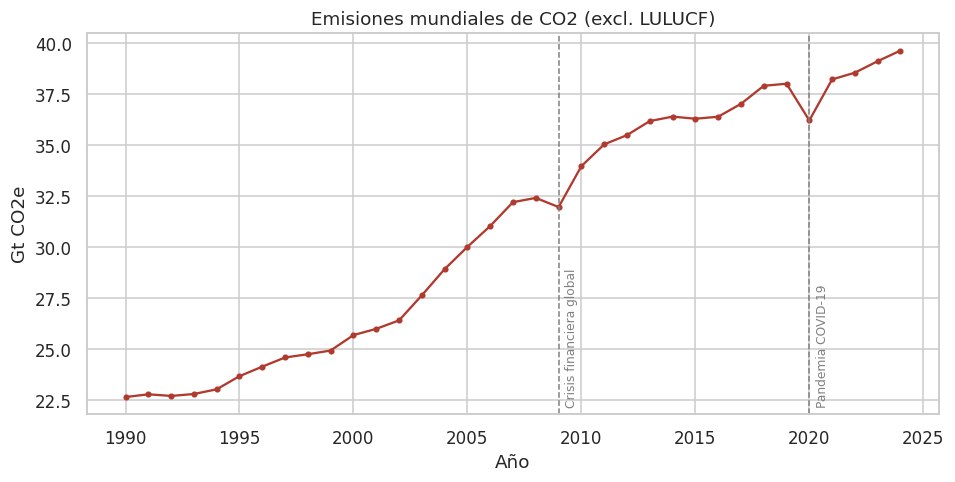

16:58:20 | INFO    | Figura guardada: reports/figures/fig01_tendencia_global_co2.png


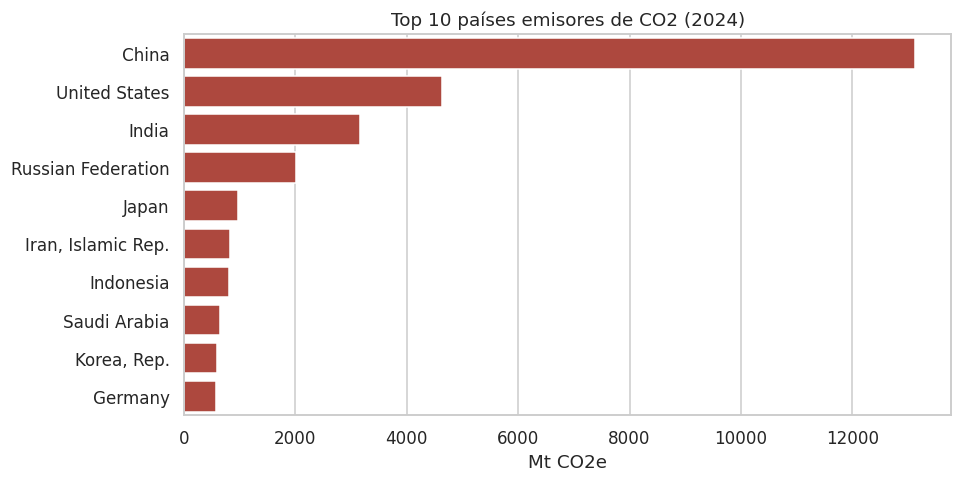

16:58:20 | INFO    | Figura guardada: reports/figures/fig02_top10_emisores.png


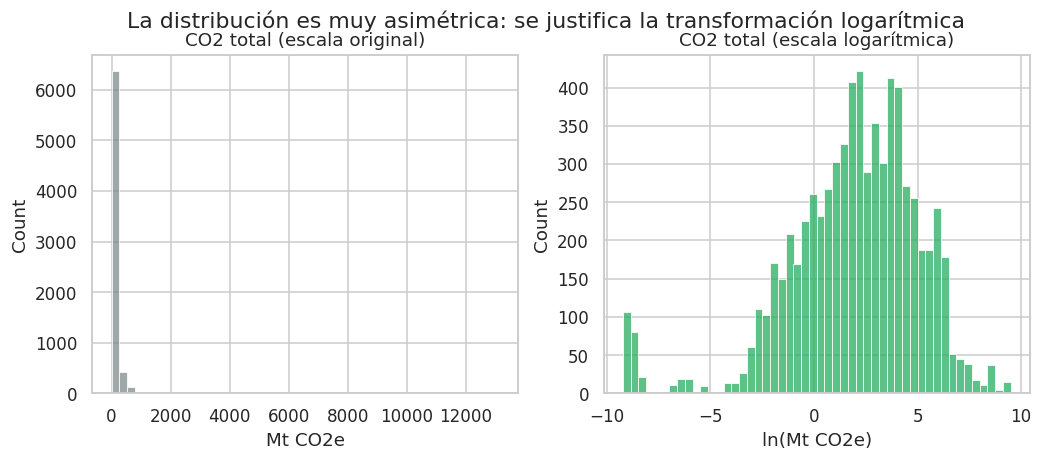

16:58:20 | INFO    | Figura guardada: reports/figures/fig03_distribucion_objetivo.png


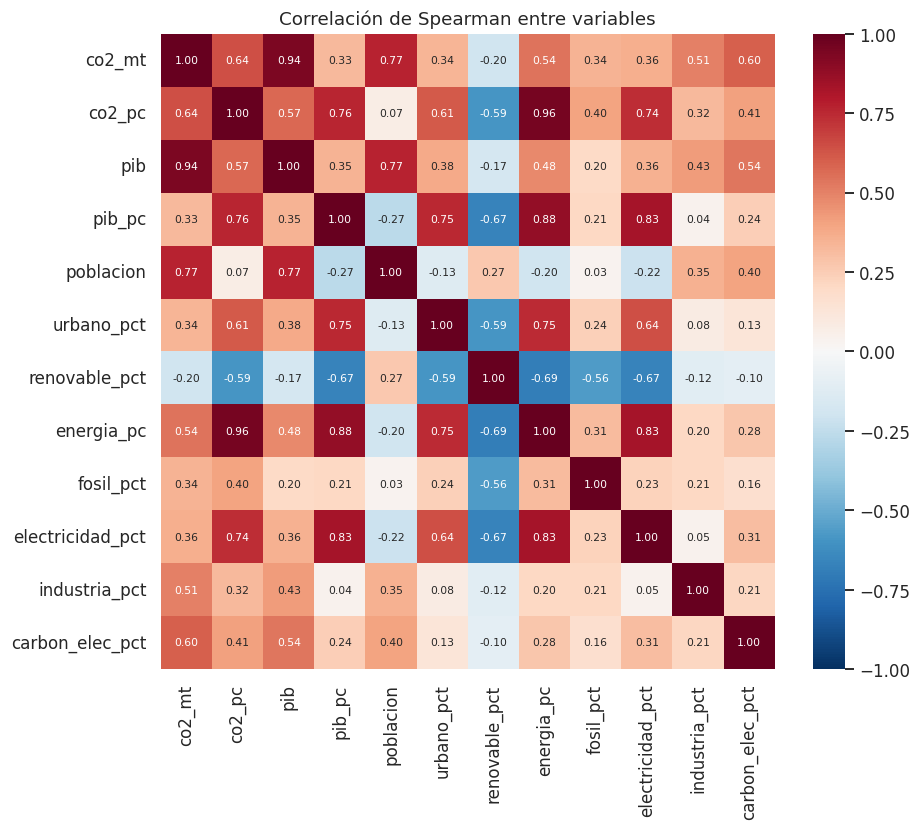

16:58:21 | INFO    | Figura guardada: reports/figures/fig04_correlaciones.png


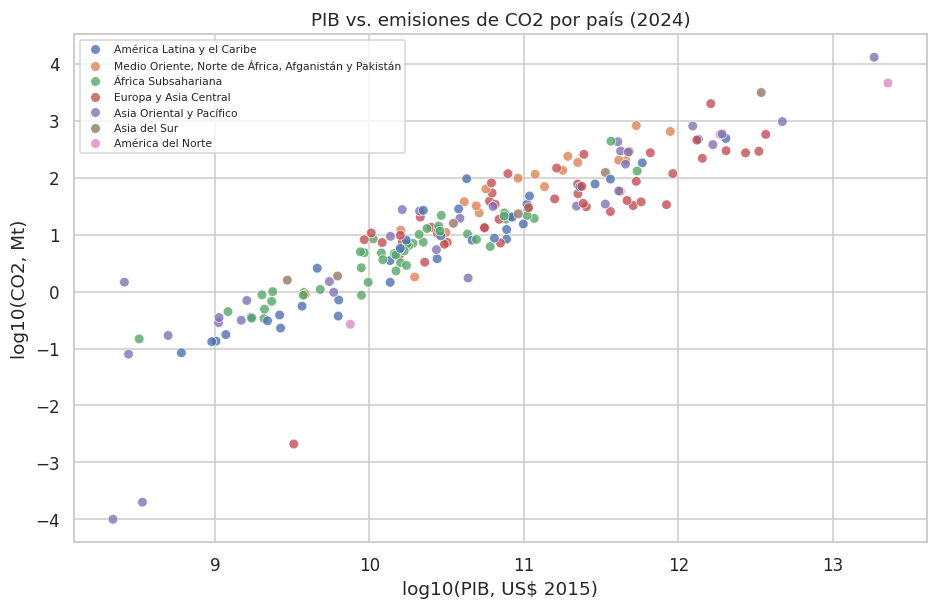

16:58:21 | INFO    | Figura guardada: reports/figures/fig05_pib_vs_co2.png


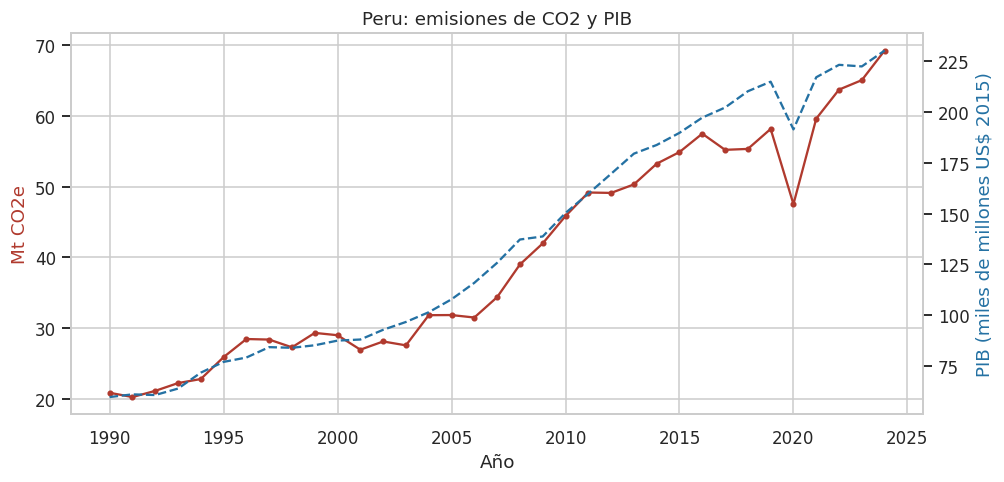

16:58:21 | INFO    | Figura guardada: reports/figures/fig06_serie_pais_referencia.png



Correlación de Spearman con el objetivo (co2_mt):
pib                 0.944
poblacion           0.770
co2_pc              0.644
carbon_elec_pct     0.598
energia_pc          0.544
industria_pct       0.505
electricidad_pct    0.360
fosil_pct           0.344
urbano_pct          0.343
pib_pc              0.327
renovable_pct      -0.198
16:58:21 | INFO    | 2.3 Evaluación de la calidad de los datos


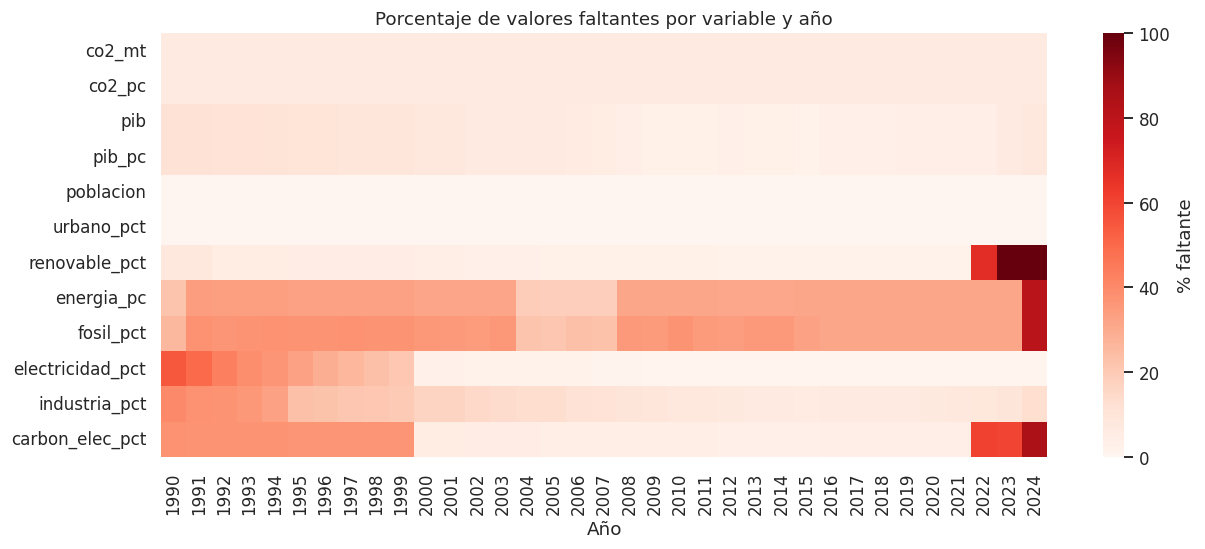

16:58:22 | INFO    | Figura guardada: reports/figures/fig07_mapa_faltantes.png



Reporte de calidad por variable:
        variable  faltantes_pct  paises_con_datos  primer_anio  ultimo_anio  fuera_de_rango  outliers_iqr
          co2_mt           6.45               203         1990         2024              70           259
          co2_pc           6.45               203         1990         2024              70           210
             pib           6.46               213         1990         2024               0            47
          pib_pc           6.46               213         1990         2024               0             0
       poblacion           0.00               217         1990         2024               0             0
      urbano_pct           0.00               217         1990         2024               0             0
   renovable_pct          11.18               212         1990         2022               0             0
      energia_pc          31.59               179         1990         2024               1             4
       fosil

16:58:22 | INFO    | Factibilidad | Países con cobertura de CO2 >= 90%            | 195 | OK


16:58:22 | INFO    | Reporte de la fase 2 guardado en reports/02_data_understanding.md


In [12]:
fase2 = fase2_data_understanding(ACTUALIZAR, PAIS_REF.upper(), requisitos)
panel, meta, calidad = fase2["panel"], fase2["meta"], fase2["calidad"]

**Vista previa del panel crudo (antes de la preparación):**

In [13]:
print(f"Panel crudo: {panel.shape[0]:,} filas x {panel.shape[1]} columnas, {panel['iso3'].nunique()} países")
panel.head(10)

Panel crudo: 7,595 filas x 14 columnas, 217 países


,iso3,anio,co2_mt,co2_pc,pib,pib_pc,poblacion,urbano_pct,renovable_pct,energia_pc,fosil_pct,electricidad_pct,industria_pct,carbon_elec_pct
0,ABW,1990,0.2010,3.203034,1.553994e+09,24763.653810,62753.0,65.432816,0.3,NaN,NaN,100.000000,NaN,NaN
1,ABW,1991,0.2264,3.435717,1.677736e+09,25460.363027,65896.0,65.400922,0.2,NaN,NaN,99.153656,NaN,NaN
2,ABW,1992,0.2508,3.634519,1.776426e+09,25743.445501,69005.0,65.390589,0.2,NaN,NaN,99.197128,NaN,NaN
3,ABW,1993,0.2516,3.414535,1.906242e+09,25870.153396,73685.0,65.384467,0.2,NaN,NaN,99.239914,NaN,NaN
4,ABW,1994,0.2858,3.683227,2.062628e+09,26581.976749,77595.0,65.380048,0.2,NaN,NaN,100.000000,NaN,NaN
5,ABW,1995,0.3144,3.939603,2.115167e+09,26504.186418,79805.0,65.376703,0.2,NaN,NaN,100.000000,15.396362,NaN
6,ABW,1996,0.2068,2.490936,2.140248e+09,25779.597928,83021.0,65.373804,0.2,NaN,NaN,100.000000,14.987449,NaN
7,ABW,1997,0.3430,3.974461,2.291069e+09,26547.416608,86301.0,65.370721,0.2,NaN,NaN,100.000000,17.133844,NaN
8,ABW,1998,0.3512,3.970560,2.336706e+09,26418.088330,88451.0,65.366825,0.2,NaN,NaN,100.000000,17.510902,NaN
9,ABW,1999,0.3559,3.969484,2.365636e+09,26384.810594,89659.0,65.361486,0.2,NaN,NaN,100.000000,15.548314,NaN


**Reporte de calidad por variable:**

In [14]:
calidad

,variable,descripcion,faltantes_pct,paises_con_datos,primer_anio,ultimo_anio,fuera_de_rango,outliers_iqr
0,co2_mt,Emisiones de CO2 totales excl. LULUCF (Mt CO2e),6.45,203,1990,2024,70,259
1,co2_pc,Emisiones de CO2 per cápita excl. LULUCF (t CO...,6.45,203,1990,2024,70,210
2,pib,PIB a precios constantes de 2015 (US$),6.46,213,1990,2024,0,47
3,pib_pc,PIB per cápita a precios constantes de 2015 (US$),6.46,213,1990,2024,0,0
4,poblacion,Población total (habitantes),0.00,217,1990,2024,0,0
5,urbano_pct,Población urbana (% del total),0.00,217,1990,2024,0,0
6,renovable_pct,Consumo de energía renovable (% del consumo fi...,11.18,212,1990,2022,0,0
7,energia_pc,Uso de energía (kg equivalente de petróleo per...,31.59,179,1990,2024,1,4
8,fosil_pct,Consumo de energía de combustibles fósiles (% ...,34.46,179,1990,2024,6,0
9,electricidad_pct,Acceso a la electricidad (% de la población),11.17,216,1990,2024,0,760


## 6. Fase 3 — Data Preparation (Preparación de los datos)
### 6.1 Selección de datos
Se descartan variables con más de 30 % de faltantes o que generan fuga de información (`co2_pc`), y se conservan los países con CO₂ válido en al menos 90 % de los años.

In [15]:
def seleccionar_datos(panel: pd.DataFrame, calidad: pd.DataFrame, bitacora: list) -> pd.DataFrame:
    """
    Selecciona:
      - Variables: se descartan las que superan el umbral de faltantes (p. ej.,
        indicadores energéticos discontinuados) y las que generan fuga de
        información (co2_pc = co2_mt / población, se deriva del objetivo).
      - Países: se conservan los que tienen CO2 válido (ver objetivo_valido) en
        al menos el 90 % de los años. Los valores no plausibles se vuelven faltantes.
    """
    descartadas = calidad.loc[calidad["faltantes_pct"] > UMBRAL_FALTANTES_VARIABLE * 100, "variable"].tolist()
    descartadas = [v for v in descartadas if v != OBJETIVO]
    fuga = ["co2_pc"]  # usada solo para validar consistencia y plausibilidad en la fase 2
    variables = [v[0] for v in INDICADORES.values() if v[0] not in descartadas + fuga]

    panel = panel.copy()
    valido = objetivo_valido(panel)
    panel.loc[~valido, OBJETIVO] = np.nan
    cobertura = valido.groupby(panel["iso3"]).mean()
    paises = cobertura[cobertura >= UMBRAL_COBERTURA_OBJETIVO].index
    sel = panel.loc[panel["iso3"].isin(paises), ["iso3", "anio"] + variables].copy()

    bitacora.append(("Selección", f"Variables descartadas por > {UMBRAL_FALTANTES_VARIABLE:.0%} de faltantes: "
                     f"{', '.join(descartadas) or 'ninguna'}"))
    bitacora.append(("Selección", "Variable descartada por fuga de información: co2_pc"))
    bitacora.append(("Selección", f"Países conservados: {len(paises)} de {panel['iso3'].nunique()} "
                     f"(cobertura de CO2 >= {UMBRAL_COBERTURA_OBJETIVO:.0%})"))
    log.info("Selección: %d variables, %d países, %d filas", len(variables), len(paises), len(sel))
    return sel

### 6.2 Limpieza de datos
Duplicados, valores fuera de rango, reconstrucción por identidades contables, interpolación por país y mediana regional. Cada valor imputado queda marcado en `imputado_<variable>` (figura fig08).

In [16]:
def limpiar_datos(df: pd.DataFrame, meta: pd.DataFrame, bitacora: list) -> pd.DataFrame:
    """
    Limpieza:
      1. Elimina duplicados país-año.
      2. Convierte valores fuera de rango en faltantes.
      3. Reconstruye PIB y población con la identidad PIB = PIB per cápita x población.
      4. Imputa por país: interpolación lineal (huecos internos <= 5 años) y
         relleno de extremos (<= 3 años). El objetivo solo se interpola en huecos
         internos: nunca se extrapolan emisiones.
      5. Imputa los faltantes restantes de covariables con la mediana regional del año.
      6. Elimina filas sin objetivo y países cuya serie quedó con huecos.
    Cada valor imputado queda marcado en una columna imputado_<variable> (1 = imputado).
    """
    variables = [c for c in df.columns if c not in ("iso3", "anio")]
    antes = df[variables].isna().sum()

    n_dup = int(df.duplicated(subset=["iso3", "anio"]).sum())
    df = df.drop_duplicates(subset=["iso3", "anio"]).sort_values(["iso3", "anio"]).reset_index(drop=True)

    n_invalidos = 0
    for var in variables:
        mascara = fuera_de_rango(df[var], var)
        n_invalidos += int(mascara.sum())
        df.loc[mascara, var] = np.nan

    # Banderas de imputación (se calculan antes de rellenar)
    for var in variables:
        df[f"imputado_{var}"] = df[var].isna().astype(int)

    # Identidades contables para recuperar niveles faltantes
    if {"pib", "pib_pc", "poblacion"} <= set(variables):
        m = df["pib"].isna() & df["pib_pc"].notna() & df["poblacion"].notna()
        df.loc[m, "pib"] = df.loc[m, "pib_pc"] * df.loc[m, "poblacion"]
        m2 = df["pib_pc"].isna() & df["pib"].notna() & df["poblacion"].notna()
        df.loc[m2, "pib_pc"] = df.loc[m2, "pib"] / df.loc[m2, "poblacion"]
        bitacora.append(("Limpieza", f"Valores de PIB/PIB per cápita reconstruidos por identidad: {int(m.sum() + m2.sum())}"))

    # Interpolación por país (en logaritmos para las variables de nivel: crecimiento geométrico)
    for var in variables:
        es_nivel = TIPO_VAR[var] == "nivel"
        serie = np.log(df[var]) if es_nivel else df[var]
        interp = serie.groupby(df["iso3"]).transform(
            lambda s: s.interpolate(method="linear", limit=LIMITE_INTERPOLACION, limit_area="inside"))
        if var != OBJETIVO:  # los extremos se rellenan solo en covariables
            interp = interp.groupby(df["iso3"]).transform(
                lambda s: s.ffill(limit=LIMITE_EXTREMOS).bfill(limit=LIMITE_EXTREMOS))
        df[var] = np.exp(interp) if es_nivel else interp

    # Faltantes restantes de covariables relativas: mediana de la región en ese año
    df = df.merge(meta[["iso3", "region"]], on="iso3", how="left")
    n_regional = 0
    for var in variables:
        if var == OBJETIVO or var in ("pib", "poblacion"):
            continue  # niveles absolutos no se imputan con medianas de otros países
        faltan = df[var].isna()
        n_regional += int(faltan.sum())
        df[var] = df[var].fillna(df.groupby(["region", "anio"])[var].transform("median"))
        df[var] = df[var].fillna(df.groupby("anio")[var].transform("median"))
    df = df.drop(columns="region")

    # Filas sin objetivo (extremos no extrapolados) y países que conservan faltantes
    filas_ini = len(df)
    df = df.dropna(subset=[OBJETIVO])
    filas_sin_objetivo = filas_ini - len(df)
    paises_incompletos = df.loc[df[variables].isna().any(axis=1), "iso3"].unique()
    df = df[~df["iso3"].isin(paises_incompletos)]

    # Países con huecos temporales (años no consecutivos) tras la limpieza
    salto = df.groupby("iso3")["anio"].diff().fillna(1)
    paises_hueco = df.loc[salto > 1, "iso3"].unique()
    df = df[~df["iso3"].isin(paises_hueco)].reset_index(drop=True)

    despues = df[variables].isna().sum()
    bitacora.append(("Limpieza", f"Duplicados país-año eliminados: {n_dup}"))
    bitacora.append(("Limpieza", f"Valores fuera de rango convertidos a faltantes: {n_invalidos}"))
    bitacora.append(("Limpieza", f"Faltantes antes de imputar: {int(antes.sum())}; imputados con mediana regional: {n_regional}"))
    bitacora.append(("Limpieza", f"Filas eliminadas por objetivo faltante en extremos: {filas_sin_objetivo}"))
    bitacora.append(("Limpieza", f"Países eliminados por faltantes irrecuperables: {', '.join(paises_incompletos) or 'ninguno'}"))
    bitacora.append(("Limpieza", f"Países eliminados por huecos temporales: {', '.join(paises_hueco) or 'ninguno'}"))
    log.info("Limpieza: %d filas, %d países, faltantes restantes = %d",
             len(df), df["iso3"].nunique(), int(despues.sum()))

    # fig08 - Faltantes antes vs. después de la limpieza
    comp = pd.DataFrame({"Antes": antes, "Después": despues})
    fig, ax = plt.subplots(figsize=(9, 4))
    comp.plot.barh(ax=ax, color=["#e74c3c", "#27ae60"])
    ax.set(title="Valores faltantes antes y después de la limpieza", xlabel="N.° de valores faltantes")
    guardar_figura(fig, "fig08_faltantes_antes_despues.png")
    return df

### 6.3 Tratamiento de outliers
Detección de saltos anómalos con el z-score robusto: los picos aislados se corrigen; los choques conocidos (2009, 2020) y los cambios estructurales se conservan (figura fig09).

In [17]:
def tratar_outliers(df: pd.DataFrame, bitacora: list) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Detecta saltos anómalos en cada serie país-variable con el z-score robusto
    de la variación anual (en logaritmos para variables de nivel). Un salto es
    anómalo si |z| > 3.5 y además su magnitud es relevante (>= 15 % en niveles o
    >= 5 puntos porcentuales), para no marcar series muy suaves. Se distinguen:
      - Picos aislados (sube y vuelve a bajar al año siguiente, o viceversa): son
        errores de registro o eventos transitorios de un solo año (p. ej., un
        conflicto armado) que no representan la tendencia a pronosticar; se
        suavizan por interpolación. El valor original queda en
        reports/03_outliers_detectados.csv y marcado en imputado_<variable>.
      - Choques conocidos (2009, 2020): son reales, se conservan y se marcan
        con las variables indicadoras choque_2009 y choque_2020.
      - Cambios de nivel persistentes: son estructurales, se conservan.
    No se eliminan los grandes emisores (China, EE. UU.): son outliers
    transversales legítimos, no errores.
    """
    df = df.sort_values(["iso3", "anio"]).reset_index(drop=True)
    variables = [c for c in df.columns if c not in ("iso3", "anio") and not c.startswith("imputado_")]
    registros = []
    for var in variables:
        es_nivel = TIPO_VAR[var] == "nivel"
        base = np.log(df[var]) if es_nivel else df[var]
        delta = base.groupby(df["iso3"]).diff()
        z = delta.groupby(df["iso3"]).transform(z_robusto)
        anomalo = (z.abs() > UMBRAL_Z_ROBUSTO) & (delta.abs() >= SALTO_MINIMO[TIPO_VAR[var]])
        anomalo_sig = anomalo.groupby(df["iso3"]).shift(-1, fill_value=False)  # año siguiente
        z_sig = z.groupby(df["iso3"]).shift(-1)
        # Pico aislado: salto anómalo seguido de un salto anómalo de signo contrario
        pico = anomalo & anomalo_sig & (np.sign(z) != np.sign(z_sig))
        shock = anomalo & df["anio"].isin(list(ANIOS_SHOCK))
        pico &= ~shock
        estructural = anomalo & ~pico & ~shock
        for idx in df.index[pico | shock | estructural]:
            registros.append({
                "iso3": df.at[idx, "iso3"], "anio": int(df.at[idx, "anio"]), "variable": var,
                "valor_original": df.at[idx, var], "z_robusto": round(float(z.at[idx]), 2),
                "tipo": "pico aislado (corregido)" if pico.at[idx] else
                        "choque conocido (conservado)" if shock.at[idx] else "cambio estructural (conservado)",
            })
        if pico.any():
            df.loc[pico, var] = np.nan
            interp = (np.log(df[var]) if es_nivel else df[var]).groupby(df["iso3"]).transform(
                lambda s: s.interpolate(limit_area="inside").ffill().bfill())
            df[var] = np.exp(interp) if es_nivel else interp
            df.loc[pico, f"imputado_{var}"] = 1

    outliers = pd.DataFrame(registros, columns=["iso3", "anio", "variable", "valor_original", "z_robusto", "tipo"])
    outliers.to_csv(DIR_REPORTES / "03_outliers_detectados.csv", index=False)
    resumen = outliers["tipo"].value_counts().to_dict() if len(outliers) else {}
    bitacora.append(("Outliers", f"Saltos anómalos detectados (|z robusto| > {UMBRAL_Z_ROBUSTO} y magnitud relevante): "
                     f"{len(outliers)} -> {resumen}"))
    log.info("Outliers: %d saltos anómalos detectados -> %s", len(outliers), resumen)

    # fig09 - Distribución de la variación anual del CO2 y umbrales de detección
    dlog = np.log(df[OBJETIVO]).groupby(df["iso3"]).diff().dropna() * 100
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.histplot(dlog.clip(-60, 60), bins=120, ax=ax, color="#5d6d7e")
    ax.set(title="Variación anual del CO2 por país (después del tratamiento)",
           xlabel="Variación logarítmica anual (%) - recortada a ±60 % para visualizar", ylabel="Frecuencia")
    guardar_figura(fig, "fig09_variacion_anual_co2.png")
    return df, outliers

### 6.4 Transformación y construcción de variables
Logaritmos, tasas de crecimiento, rezagos del objetivo y de las covariables (`_rezago1`), tendencia e indicadoras `choque_2009` y `choque_2020`. Todas las variables derivadas del CO₂ usan solo información de años anteriores para evitar fuga de información.

In [18]:
def transformar_datos(df: pd.DataFrame, bitacora: list) -> pd.DataFrame:
    """
    Construye las variables que usará el modelo de forecasting:
      - Logaritmos de las variables de nivel (reducen asimetría y heterocedasticidad).
      - Tasas de crecimiento anual del PIB y la población.
      - Rezagos del objetivo: log_co2 en t-1, t-2, t-3 (log_co2_rezago1..3),
        su variación anual rezagada y la media móvil de 3 años rezagada.
      - Rezagos (t-1) de las covariables y de la intensidad de carbono (sufijo _rezago1).
      - Tendencia (años desde 1990) e indicadoras de choques conocidos
        (choque_2009, choque_2020).
    Todas las variables derivadas del objetivo usan SOLO información de años
    anteriores (shift >= 1) para evitar fuga de información.
    El escalado (estandarización) NO se hace aquí: debe ajustarse solo con el
    conjunto de entrenamiento en la fase de modelado.
    """
    df = df.sort_values(["iso3", "anio"]).reset_index(drop=True)
    g = df.groupby("iso3")
    covariables = [c for c in df.columns if c not in ("iso3", "anio", OBJETIVO) and not c.startswith("imputado_")]

    # Objetivo transformado
    df["log_co2"] = np.log(df[OBJETIVO])

    # Logaritmos de niveles
    for var in covariables:
        if TIPO_VAR[var] == "nivel":
            df[f"log_{var}"] = np.log(df[var])

    # Crecimientos anuales (%)
    if "pib" in df:
        df["crec_pib_pct"] = g["pib"].pct_change() * 100
    if "poblacion" in df:
        df["crec_poblacion_pct"] = g["poblacion"].pct_change() * 100

    # Rezagos del objetivo (información disponible al momento de pronosticar)
    for k in range(1, N_REZAGOS_OBJETIVO + 1):
        df[f"log_co2_rezago{k}"] = g["log_co2"].shift(k)
    df["crec_co2_rezago1"] = (df["log_co2_rezago1"] - df["log_co2_rezago2"]) * 100
    df["log_co2_media3_rezago1"] = g["log_co2"].transform(lambda s: s.shift(1).rolling(3).mean())

    # Intensidad de carbono (kg CO2 por US$ de PIB), solo rezagada
    if "pib" in df:
        intensidad = df[OBJETIVO] * 1e9 / df["pib"]
        df["intensidad_carbono_rezago1"] = intensidad.groupby(df["iso3"]).shift(1)

    # Rezagos t-1 de las covariables
    for var in covariables:
        nombre = f"log_{var}" if TIPO_VAR[var] == "nivel" else var
        df[f"{nombre}_rezago1"] = df.groupby("iso3")[nombre].shift(1)

    # Tendencia e indicadoras de choques conocidos (1 en el año del choque, 0 en el resto)
    df["tendencia"] = df["anio"] - ANIO_INICIO
    for anio, evento in ANIOS_SHOCK.items():
        df[f"choque_{anio}"] = (df["anio"] == anio).astype(int)

    # Se eliminan las primeras filas de cada país (sin historia suficiente para los rezagos)
    filas_ini = len(df)
    columnas_rezago = [c for c in df.columns if "rezago" in c or c.startswith("crec_")]
    df = df.dropna(subset=columnas_rezago).reset_index(drop=True)
    bitacora.append(("Transformación", f"Variables creadas: log, crecimientos, {N_REZAGOS_OBJETIVO} rezagos del objetivo, "
                     f"rezagos t-1 de covariables, tendencia e indicadoras de choque {list(ANIOS_SHOCK)}"))
    bitacora.append(("Transformación", f"Filas iniciales sin historia suficiente eliminadas: {filas_ini - len(df)}"))
    log.info("Transformación: %d columnas, %d filas", df.shape[1], len(df))
    return df

### 6.5 Integración de datos
Unión con los metadatos de países (región y nivel de ingreso, en español) y creación de indicadoras one-hot `reg_*` e `ing_*`.

In [19]:
def integrar_datos(df: pd.DataFrame, meta: pd.DataFrame, bitacora: list) -> pd.DataFrame:
    """
    Integra el panel de indicadores con la tabla de metadatos de países (segunda
    fuente de la API): nombre, región y nivel de ingreso (ya traducidos al
    español). Además crea variables indicadoras (one-hot, 1/0) de región
    (reg_<region>) y nivel de ingreso (ing_<nivel>) para el modelado.
    """
    info = meta.loc[~meta["es_agregado"], ["iso3", "pais", "region", "nivel_ingreso"]]
    df = df.merge(info, on="iso3", how="left", validate="many_to_one")
    # Nombre en español -> sufijo de columna (p. ej., "América del Norte" -> "america_norte")
    sufijo_reg = {es: suf for es, suf in REGIONES_ES.values()}
    sufijo_ing = {es: suf for es, suf in INGRESOS_ES.values()}
    dummies = pd.concat([
        pd.get_dummies(df["region"].map(sufijo_reg), prefix="reg", dtype=int),
        pd.get_dummies(df["nivel_ingreso"].map(sufijo_ing), prefix="ing", dtype=int),
    ], axis=1)
    df = pd.concat([df, dummies], axis=1)
    bitacora.append(("Integración", f"Unión con metadatos de países (región, ingreso); {dummies.shape[1]} variables one-hot creadas"))
    log.info("Integración: %d columnas tras unir metadatos", df.shape[1])
    return df

### 6.6 Partición temporal (solo etiqueta, sin entrenar)
Entrenamiento ≤ 2016, validación 2017–2020 y prueba 2021–2024. Aquí **no se entrena nada**; solo se etiqueta cada fila.

In [20]:
def particionar_temporalmente(df: pd.DataFrame, bitacora: list) -> pd.DataFrame:
    """
    Etiqueta cada fila como entrenamiento / validación / prueba según el año.
    En forecasting la partición debe respetar el orden temporal (no aleatoria)
    para no usar el futuro al predecir el pasado. Aquí NO se entrena nada.
    """
    df["particion"] = ""
    for nombre, (desde, hasta) in PARTICION.items():
        mascara = (df["anio"] <= hasta) & ((df["anio"] >= desde) if desde else True)
        df.loc[mascara, "particion"] = nombre
    conteo = df["particion"].value_counts().to_dict()
    bitacora.append(("Partición", f"Partición temporal sugerida para el modelado: {conteo}"))
    log.info("Partición temporal: %s", conteo)
    return df

### 6.7 Validación final (Quality Assurance) y diccionario de datos
Nueve controles automáticos verifican que el dataset final cumpla los requisitos de la fase 1.

In [21]:
def validar_dataset_final(df: pd.DataFrame, requisitos: dict) -> pd.DataFrame:
    """
    Verifica automáticamente que el dataset final cumpla los requisitos de
    calidad definidos en la fase 1. Si algún control falla, el programa termina
    con código de error para que el problema no pase inadvertido.
    """
    numericas = df.select_dtypes("number").columns
    porcentajes = [c for c in df.columns if TIPO_VAR.get(c) == "porcentaje"]
    anios_consec = df.groupby("iso3")["anio"].apply(lambda s: bool((s.diff().dropna() == 1).all())).all()
    columnas_objetivo_t = {"log_co2", OBJETIVO}
    fuga = [c for c in df.columns if ("co2" in c or "intensidad" in c)
            and c not in columnas_objetivo_t and "rezago" not in c and not c.startswith("imputado_")]
    checks = [
        ("Sin valores nulos", int(df.isna().sum().sum()), int(df.isna().sum().sum()) <= requisitos["max_nulos_dataset_final"]),
        ("Sin duplicados país-año", int(df.duplicated(["iso3", "anio"]).sum()),
         int(df.duplicated(["iso3", "anio"]).sum()) <= requisitos["max_duplicados_pais_anio"]),
        (f"N.° de países >= {requisitos['min_paises']}", df["iso3"].nunique(), df["iso3"].nunique() >= requisitos["min_paises"]),
        ("Porcentajes en [0, 100]", porcentajes, bool(((df[porcentajes] >= 0) & (df[porcentajes] <= 100)).all().all())),
        ("Objetivo estrictamente positivo", round(float(df[OBJETIVO].min()), 4), bool((df[OBJETIVO] > 0).all())),
        ("Sin valores infinitos", int(np.isinf(df[numericas]).sum().sum()), not np.isinf(df[numericas]).any().any()),
        ("Años consecutivos en cada país", bool(anios_consec), bool(anios_consec)),
        ("Sin fuga de información (derivadas del CO2 solo rezagadas)", fuga or "ninguna", len(fuga) == 0),
        ("Todas las particiones con datos", df["particion"].value_counts().to_dict(),
         set(df["particion"]) == set(PARTICION)),
    ]
    resultado = pd.DataFrame(checks, columns=["control", "valor", "cumple"])
    resultado["valor"] = resultado["valor"].astype(str)
    print("\nControles de calidad del dataset final:")
    for _, fila in resultado.iterrows():
        print(f"  [{'OK' if fila['cumple'] else 'FALLA'}] {fila['control']:<58} -> {fila['valor']}")
    return resultado


def generar_diccionario(df: pd.DataFrame) -> pd.DataFrame:
    """Crea el diccionario de datos del dataset final (nombre, tipo, descripción)."""
    def describir(col: str) -> str:
        if col in DESC_VAR:
            return DESC_VAR[col]
        base = {"iso3": "Código ISO3 del país", "anio": "Año", "pais": "Nombre del país",
                "region": "Región del Banco Mundial", "nivel_ingreso": "Nivel de ingreso del Banco Mundial",
                "log_co2": "OBJETIVO transformado: ln(CO2 Mt)", "tendencia": f"Años desde {ANIO_INICIO}",
                "crec_pib_pct": "Crecimiento anual del PIB (%)", "crec_poblacion_pct": "Crecimiento anual de la población (%)",
                "crec_co2_rezago1": "Variación anual del CO2 en t-1 (%, log)",
                "log_co2_media3_rezago1": "Media móvil de 3 años de log_co2 (t-1, t-2, t-3)",
                "intensidad_carbono_rezago1": "Intensidad de carbono en t-1 (kg CO2 / US$ de PIB)",
                "particion": "Partición temporal sugerida (entrenamiento/validacion/prueba)"}
        if col in base:
            return base[col]
        if col.startswith("imputado_"):
            return f"1 si {col[9:]} fue imputado en la limpieza"
        if col.startswith("choque_"):
            return f"1 si el año es {col[7:]} ({ANIOS_SHOCK.get(int(col[7:]), '')})"
        if col.startswith("reg_"):
            nombre = {suf: es for es, suf in REGIONES_ES.values()}.get(col[4:], col[4:])
            return f"1 si el país pertenece a la región {nombre}"
        if col.startswith("ing_"):
            nombre = {suf: es for es, suf in INGRESOS_ES.values()}.get(col[4:], col[4:])
            return f"1 si el nivel de ingreso del país es {nombre.lower()}"
        if col.startswith("log_co2_rezago"):
            return f"log_co2 rezagado {col[-1]} año(s)"
        if col.endswith("_rezago1"):
            raiz = col[:-8].removeprefix("log_")
            return f"{'Logaritmo de ' if col.startswith('log_') else ''}{DESC_VAR.get(raiz, raiz)} en t-1"
        if col.startswith("log_"):
            return f"Logaritmo natural de {DESC_VAR.get(col[4:], col[4:])}"
        return ""
    return pd.DataFrame({"columna": df.columns, "tipo": df.dtypes.astype(str).values,
                         "descripcion": [describir(c) for c in df.columns]})

### 6.8 Ejecución de la fase 3
La función `fase3_data_preparation` ejecuta en orden los pasos 6.1 a 6.7 y guarda los resultados.

**Resultado esperado:** `data/processed/co2_dataset_preparado.csv` (5 888 filas × 58 columnas, 184 países, 1993–2024), diccionario de datos, reportes `03_*` y 9/9 controles cumplidos.

In [22]:
def fase3_data_preparation(panel: pd.DataFrame, meta: pd.DataFrame, calidad: pd.DataFrame,
                           requisitos: dict) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Orquesta la fase 3: selección, limpieza, outliers, transformación,
    integración, partición temporal y validación final.

    Resultado esperado:
        - data/processed/co2_dataset_preparado.csv: 5 888 filas x 58 columnas,
          184 países, 1993-2024, sin nulos ni duplicados
        - data/processed/diccionario_datos.csv (descripción de cada columna)
        - reports/03_data_preparation.md (bitácora de decisiones y controles),
          reports/03_outliers_detectados.csv (986 saltos anómalos) y fig08-fig09
        - 9/9 controles de calidad cumplidos
    """
    titulo("FASE 3 - DATA PREPARATION")
    bitacora: list[tuple[str, str]] = []

    log.info("3.1 Selección de datos")
    df = seleccionar_datos(panel, calidad, bitacora)
    log.info("3.2 Limpieza de datos")
    df = limpiar_datos(df, meta, bitacora)
    log.info("3.3 Tratamiento de outliers")
    df, outliers = tratar_outliers(df, bitacora)
    log.info("3.4 Transformación de datos")
    df = transformar_datos(df, bitacora)
    log.info("3.5 Integración de datos")
    df = integrar_datos(df, meta, bitacora)
    log.info("3.6 Partición temporal")
    df = particionar_temporalmente(df, bitacora)

    # Orden final de columnas: claves, objetivo, covariables, banderas, partición
    claves = ["iso3", "pais", "region", "nivel_ingreso", "anio"]
    flags = [c for c in df.columns if c.startswith("imputado_")]
    resto = [c for c in df.columns if c not in claves + flags + ["particion", OBJETIVO, "log_co2"]]
    df = df[claves + [OBJETIVO, "log_co2"] + resto + flags + ["particion"]]

    log.info("3.7 Validación final (Quality Assurance)")
    controles = validar_dataset_final(df, requisitos)

    # Guardado de resultados
    ruta = DIR_PROCESADO / "co2_dataset_preparado.csv"
    df.to_csv(ruta, index=False)
    diccionario = generar_diccionario(df)
    diccionario.to_csv(DIR_PROCESADO / "diccionario_datos.csv", index=False)
    log.info("Dataset preparado guardado en %s (%d filas x %d columnas)", ruta.relative_to(BASE_DIR), *df.shape)

    md = [
        "# Fase 3 - Data Preparation",
        f"Dataset final: `data/processed/co2_dataset_preparado.csv` - **{df.shape[0]:,} filas x {df.shape[1]} columnas**, "
        f"{df['iso3'].nunique()} países, años {df['anio'].min()}-{df['anio'].max()}.",
        "## Bitácora de decisiones",
        tabla_markdown(pd.DataFrame(bitacora, columns=["etapa", "decision"])),
        "## Outliers detectados (resumen)",
        tabla_markdown(outliers.groupby(["variable", "tipo"]).size().rename("n").reset_index())
        if len(outliers) else "No se detectaron saltos anómalos.",
        "Detalle completo en `reports/03_outliers_detectados.csv`.",
        "## Controles de calidad del dataset final",
        tabla_markdown(controles),
        "## Diccionario de datos",
        tabla_markdown(diccionario),
    ]
    (DIR_REPORTES / "03_data_preparation.md").write_text("\n\n".join(md), encoding="utf-8")
    log.info("Reporte de la fase 3 guardado en reports/03_data_preparation.md")
    return df, controles


 FASE 3 - DATA PREPARATION
16:58:22 | INFO    | 3.1 Selección de datos


16:58:22 | INFO    | Selección: 9 variables, 195 países, 6825 filas


16:58:22 | INFO    | 3.2 Limpieza de datos


16:58:23 | INFO    | Limpieza: 6440 filas, 184 países, faltantes restantes = 0


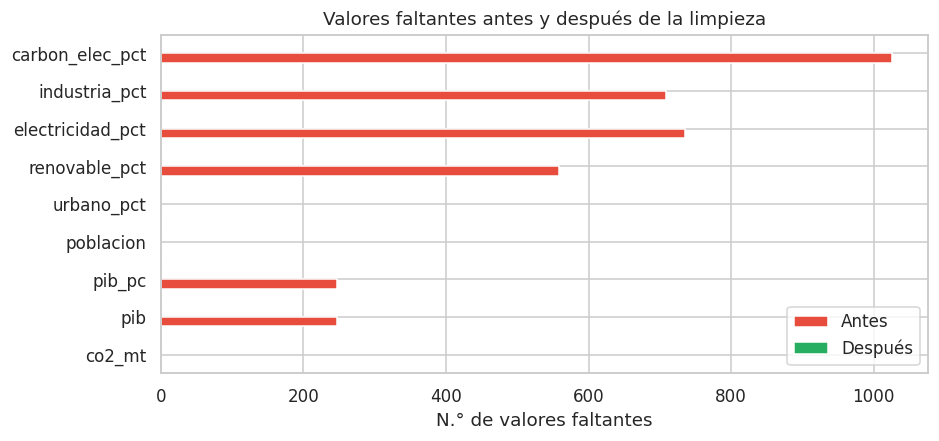

16:58:23 | INFO    | Figura guardada: reports/figures/fig08_faltantes_antes_despues.png


16:58:23 | INFO    | 3.3 Tratamiento de outliers


16:58:24 | INFO    | Outliers: 986 saltos anómalos detectados -> {'cambio estructural (conservado)': 811, 'choque conocido (conservado)': 96, 'pico aislado (corregido)': 79}


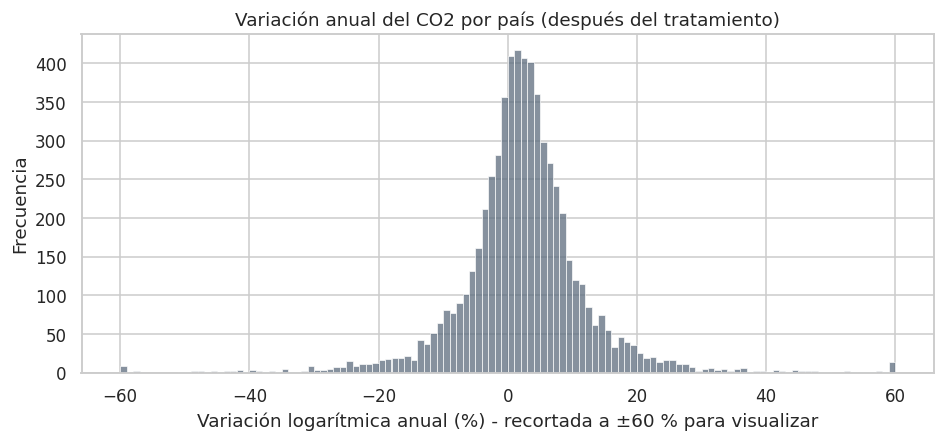

16:58:24 | INFO    | Figura guardada: reports/figures/fig09_variacion_anual_co2.png


16:58:24 | INFO    | 3.4 Transformación de datos


16:58:24 | INFO    | Transformación: 43 columnas, 5888 filas


16:58:24 | INFO    | 3.5 Integración de datos


16:58:24 | INFO    | Integración: 57 columnas tras unir metadatos


...

16:58:24 | INFO    | Partición temporal: {'entrenamiento': 4416, 'validacion': 736, 'prueba': 736}


16:58:24 | INFO    | 3.7 Validación final (Quality Assurance)



Controles de calidad del dataset final:
  [OK] Sin valores nulos                                          -> 0
  [OK] Sin duplicados país-año                                    -> 0
  [OK] N.° de países >= 150                                       -> 184
  [OK] Porcentajes en [0, 100]                                    -> ['urbano_pct', 'renovable_pct', 'electricidad_pct', 'industria_pct', 'carbon_elec_pct']
  [OK] Objetivo estrictamente positivo                            -> 0.0012
  [OK] Sin valores infinitos                                      -> 0
  [OK] Años consecutivos en cada país                             -> True
  [OK] Sin fuga de información (derivadas del CO2 solo rezagadas) -> ninguna
  [OK] Todas las particiones con datos                            -> {'entrenamiento': 4416, 'validacion': 736, 'prueba': 736}


16:58:25 | INFO    | Dataset preparado guardado en data/processed/co2_dataset_preparado.csv (5888 filas x 58 columnas)


16:58:25 | INFO    | Reporte de la fase 3 guardado en reports/03_data_preparation.md


In [23]:
df, controles = fase3_data_preparation(panel, meta, calidad, requisitos)

**Controles de calidad del dataset final:**

In [24]:
controles

,control,valor,cumple
0,Sin valores nulos,0,True
1,Sin duplicados país-año,0,True
2,N.° de países >= 150,184,True
3,"Porcentajes en [0, 100]","['urbano_pct', 'renovable_pct', 'electricidad_...",True
4,Objetivo estrictamente positivo,0.0012,True
5,Sin valores infinitos,0,True
6,Años consecutivos en cada país,True,True
7,Sin fuga de información (derivadas del CO2 sol...,ninguna,True
8,Todas las particiones con datos,"{'entrenamiento': 4416, 'validacion': 736, 'pr...",True


**Vista previa del dataset preparado:**

In [25]:
df.head(10)

,iso3,pais,region,nivel_ingreso,anio,co2_mt,log_co2,pib,pib_pc,poblacion,...,imputado_co2_mt,imputado_pib,imputado_pib_pc,imputado_poblacion,imputado_urbano_pct,imputado_renovable_pct,imputado_electricidad_pct,imputado_industria_pct,imputado_carbon_elec_pct,particion
0,ABW,Aruba,América Latina y el Caribe,Ingreso alto,1993,0.251600,-1.379915,1.906242e+09,25870.153396,73685.0,...,0,0,0,0,0,0,0,1,1,entrenamiento
1,ABW,Aruba,América Latina y el Caribe,Ingreso alto,1994,0.285800,-1.252463,2.062628e+09,26581.976749,77595.0,...,0,0,0,0,0,0,0,1,1,entrenamiento
2,ABW,Aruba,América Latina y el Caribe,Ingreso alto,1995,0.314400,-1.157089,2.115167e+09,26504.186418,79805.0,...,0,0,0,0,0,0,0,0,1,entrenamiento
3,ABW,Aruba,América Latina y el Caribe,Ingreso alto,1996,0.328389,-1.113557,2.140248e+09,25779.597928,83021.0,...,1,0,0,0,0,0,0,0,1,entrenamiento
4,ABW,Aruba,América Latina y el Caribe,Ingreso alto,1997,0.343000,-1.070025,2.291069e+09,26547.416608,86301.0,...,0,0,0,0,0,0,0,0,1,entrenamiento
5,ABW,Aruba,América Latina y el Caribe,Ingreso alto,1998,0.351200,-1.046399,2.336706e+09,26418.088330,88451.0,...,0,0,0,0,0,0,0,0,1,entrenamiento
6,ABW,Aruba,América Latina y el Caribe,Ingreso alto,1999,0.355900,-1.033105,2.365636e+09,26384.810594,89659.0,...,0,0,0,0,0,0,0,0,1,entrenamiento
7,ABW,Aruba,América Latina y el Caribe,Ingreso alto,2000,0.268900,-1.313416,2.545966e+09,28104.895436,90588.0,...,0,0,0,0,0,0,0,0,0,entrenamiento
8,ABW,Aruba,América Latina y el Caribe,Ingreso alto,2001,0.271900,-1.302321,2.652439e+09,29007.738696,91439.0,...,0,0,0,0,0,0,0,0,0,entrenamiento
9,ABW,Aruba,América Latina y el Caribe,Ingreso alto,2002,0.297000,-1.214023,2.627374e+09,28535.463948,92074.0,...,0,0,0,0,0,0,0,0,0,entrenamiento


**Diccionario de datos:**

In [26]:
with pd.option_context("display.max_rows", 100, "display.max_colwidth", 90):
    display(pd.read_csv(DIR_PROCESADO / "diccionario_datos.csv"))

,columna,tipo,descripcion
0,iso3,str,Código ISO3 del país
1,pais,str,Nombre del país
2,region,str,Región del Banco Mundial
3,nivel_ingreso,str,Nivel de ingreso del Banco Mundial
4,anio,int64,Año
5,co2_mt,float64,Emisiones de CO2 totales excl. LULUCF (Mt CO2e)
6,log_co2,float64,OBJETIVO transformado: ln(CO2 Mt)
7,pib,float64,PIB a precios constantes de 2015 (US$)
8,pib_pc,float64,PIB per cápita a precios constantes de 2015 (US$)
9,poblacion,float64,Población total (habitantes)


## 7. Resumen
Equivale al bloque final de `main()` en `main.py`.

In [27]:
titulo("RESUMEN")
print(f"Países en el dataset final : {df['iso3'].nunique()}")
print(f"Periodo                    : {df['anio'].min()}-{df['anio'].max()}")
print(f"Dimensiones                : {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"Controles de calidad       : {int(controles['cumple'].sum())}/{len(controles)} cumplidos")
print(f"Tiempo de ejecución        : {time.time() - inicio:.1f} s")
print("Salidas: data/processed/ (dataset y diccionario), reports/ (reportes y figuras)")
print("Siguiente fase (fuera de alcance): Modeling con el dataset preparado.")

# En main.py el programa termina con código 1 si algún control falla; aquí se avisa con un error visible
assert controles["cumple"].all(), "Algún control de calidad no se cumplió: revisar la tabla de controles"


 RESUMEN
Países en el dataset final : 184
Periodo                    : 1993-2024
Dimensiones                : 5,888 filas x 58 columnas
Controles de calidad       : 9/9 cumplidos
Tiempo de ejecución        : 5.7 s
Salidas: data/processed/ (dataset y diccionario), reports/ (reportes y figuras)
Siguiente fase (fuera de alcance): Modeling con el dataset preparado.


---
**Salidas generadas** (idénticas a las de `main.py`):
- `data/raw/` — datos crudos de la API (caché)
- `data/processed/co2_dataset_preparado.csv` y `diccionario_datos.csv`
- `reports/01_*`, `02_*`, `03_*` — reportes de cada fase
- `reports/figures/fig01` a `fig09` — gráficos

La siguiente fase de CRISP-ML(Q) (Modeling) queda fuera del alcance de este entregable.